<a href="https://colab.research.google.com/github/pevu97/MIssles-and-Rocket-Identification/blob/main/missile_rocket.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import plotly.graph_objects as go
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import TensorBoard


In [3]:
!wget https://storage.googleapis.com/esmartdata-courses-files/ann-course/flying-vehicles.zip
!unzip -q flying-vehicles.zip

--2026-03-05 13:59:47--  https://storage.googleapis.com/esmartdata-courses-files/ann-course/flying-vehicles.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 192.178.163.207, 173.194.202.207, 173.194.203.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|192.178.163.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1540232238 (1.4G) [application/x-zip-compressed]
Saving to: ‘flying-vehicles.zip’

flying-vehicles.zip 100%[===================>]   1.43G  23.5MB/s    in 65s     

2026-03-05 14:00:53 (22.8 MB/s) - ‘flying-vehicles.zip’ saved [1540232238/1540232238]



In [4]:
!rm -rf ./images

In [5]:
base_dir = './data/planes'
raw_no_of_files = {}
classes = ['drone', 'fighter-jet', 'helicopter', 'missile', 'passenger-plane', 'rocket']
for dir in classes:
  raw_no_of_files[dir] = len(os.listdir(os.path.join(base_dir, dir)))

raw_no_of_files.items()

dict_items([('drone', 1332), ('fighter-jet', 1867), ('helicopter', 1387), ('missile', 1334), ('passenger-plane', 1424), ('rocket', 1186)])

In [6]:
data_dir = './images'

if not os.path.exists(data_dir):
  os.mkdir(data_dir)

train_dir = os.path.join(data_dir, 'train')
valid_dir = os.path.join(data_dir, 'valid')
test_dir = os.path.join(data_dir, 'test')

for directory in (train_dir, valid_dir, test_dir):
  if not os.path.exists(directory):
    os.mkdir(directory)

train_missile_dir = os.path.join(train_dir, 'missile')
train_rocket_dir = os.path.join(train_dir, 'rocket')

valid_missile_dir = os.path.join(valid_dir, 'missile')
valid_rocket_dir = os.path.join(valid_dir, 'rocket')

test_missile_dir = os.path.join(test_dir, 'missile')
test_rocket_dir = os.path.join(test_dir, 'rocket')

dirs = [train_missile_dir, train_rocket_dir, valid_missile_dir, valid_rocket_dir, test_missile_dir, test_rocket_dir]

for dir in dirs:
  if not os.path.exists(dir):
    os.mkdir(dir)

In [7]:
missile_fnames = os.listdir(os.path.join(base_dir, 'missile'))
rocket_fnames = os.listdir(os.path.join(base_dir, 'rocket'))


In [8]:
missile_fnames = [fname for fname in missile_fnames if fname.split('.')[1].lower() in ['jpg', 'png', 'jpeg']]
rocket_fnames = [fname for fname in rocket_fnames if fname.split('.')[1].lower() in ['jpg', 'png', 'jpeg']]


In [9]:
size = min(len(missile_fnames), len(rocket_fnames))
size

1173

In [10]:
train_size = int(np.floor(0.7 * size))
valid_size = int(np.floor(0.2 * size))
test_size = size - train_size - valid_size

train_size, valid_size, test_size

train_idx = train_size
valid_idx = train_size + valid_size
test_idx = train_size + valid_size + test_size

In [11]:

for i, fname in enumerate(missile_fnames):
    if i <= train_idx:
        src = os.path.join(base_dir, 'missile', fname)
        dst = os.path.join(train_missile_dir, fname)
        shutil.copyfile(src, dst)
    elif train_idx < i <= valid_idx:
        src = os.path.join(base_dir, 'missile', fname)
        dst = os.path.join(valid_missile_dir, fname)
        shutil.copyfile(src, dst)
    elif valid_idx < i < test_idx:
        src = os.path.join(base_dir, 'missile', fname)
        dst = os.path.join(test_missile_dir, fname)
        shutil.copyfile(src, dst)

for i, fname in enumerate(rocket_fnames):
    if i <= train_idx:
        src = os.path.join(base_dir, 'rocket', fname)
        dst = os.path.join(train_rocket_dir, fname)
        shutil.copyfile(src, dst)
    elif train_idx < i <= valid_idx:
        src = os.path.join(base_dir, 'rocket', fname)
        dst = os.path.join(valid_rocket_dir, fname)
        shutil.copyfile(src, dst)
    elif valid_idx < i < test_idx:
        src = os.path.join(base_dir, 'rocket', fname)
        dst = os.path.join(test_rocket_dir, fname)
        shutil.copyfile(src, dst)

print('missile - zbiór treningowy', len(os.listdir(train_missile_dir)))
print('missile - zbiór walidacyjny', len(os.listdir(valid_missile_dir)))
print('missile - zbiór testowy', len(os.listdir(test_missile_dir)))

print('rocket - zbiór treningowy', len(os.listdir(train_rocket_dir)))
print('rocket - zbiór testowy', len(os.listdir(test_rocket_dir)))

missile - zbiór treningowy 822
missile - zbiór walidacyjny 234
missile - zbiór testowy 117
rocket - zbiór treningowy 822
rocket - zbiór testowy 117


In [12]:
type(train_size)

int

In [13]:
train_size

821

(np.float64(-0.5), np.float64(999.5), np.float64(540.5), np.float64(-0.5))

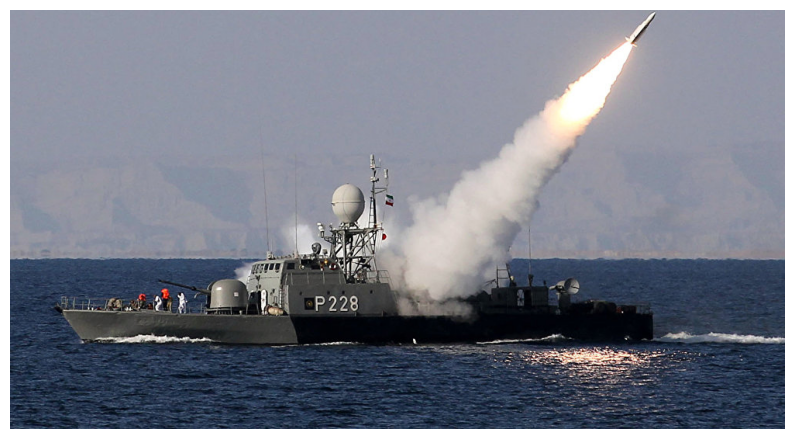

In [26]:
idx = 81 #@param {type: 'slider', min:0, max:821}
names_mapping = dict(enumerate(missile_fnames))
img_path = os.path.join(train_missile_dir, names_mapping[idx])

img = image.load_img(img_path)

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.grid(False)
plt.axis(False)

(np.float64(-0.5), np.float64(878.5), np.float64(484.5), np.float64(-0.5))

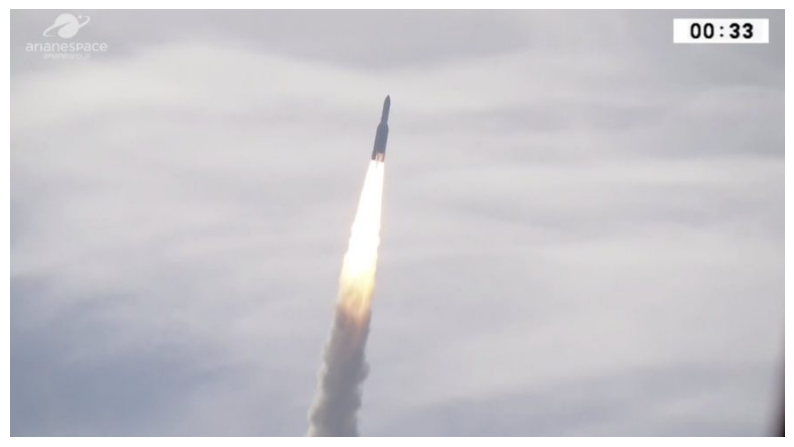

In [41]:
idx = 349 #@param {type: 'slider', min:0, max:821}
names_mapping = dict(enumerate(rocket_fnames))
img_path = os.path.join(train_rocket_dir, names_mapping[idx])

img = image.load_img(img_path)

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.grid(False)
plt.axis(False)

In [48]:
train_datagen = ImageDataGenerator(
    rotation_range=40,
    rescale=1./255.,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1./255.)

train_generator = train_datagen.flow_from_directory(directory=train_dir,
                                                    target_size=(150, 150),
                                                    batch_size=32,
                                                    class_mode='binary')

valid_generator = valid_datagen.flow_from_directory(directory=valid_dir,
                                                    target_size=(150, 150),
                                                    batch_size=32,
                                                    class_mode='binary')


Found 1644 images belonging to 2 classes.
Found 468 images belonging to 2 classes.


In [49]:
def display_augmented_images(directory, idx):
  fnames = [os.path.join(directory, fname) for fname in os.listdir(directory)]
  img_path = fnames[idx]
  img = image.load_img(img_path, target_size=(150, 150))

  x = image.img_to_array(img)
  x = x.reshape((1, ) + x.shape)

  i = 1
  plt.figure(figsize=(16, 8))
  for batch in train_datagen.flow(x, batch_size = 1):
    plt.subplot(3, 4, i)
    plt.grid(False)
    imgplot = plt.imshow(image.array_to_img(batch[0]))
    i += 1
    if i % 13 ==0:
      break

In [ ]:
#@title Zbiór treningowy Missiles:
idx = 1 #@param {type: 'slider', 'min:0, max}